### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [ ]:
data = pd.read_csv('data/coupons.csv')

In [ ]:
data.head()

2. Investigate the dataset for missing or problematic data.

In [14]:
# Shape and overview
print("Shape:", data.shape)
print("\nColumn dtypes:\n", data.dtypes)

# Missing values (NaN)
missing = data.isna().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_report = pd.DataFrame({"count": missing, "pct": missing_pct})
print("\nColumns with missing values:")
print(missing_report[missing_report["count"] > 0].sort_values("count", ascending=False))

# `car` is almost entirely missing; frequency columns also have gaps
print("\nNon-null `car` values:", data["car"].notna().sum(), "of", len(data))

# Duplicate rows
dup_count = data.duplicated().sum()
print(f"\nFully duplicate rows: {dup_count} ({100 * dup_count / len(data):.2f}%)")

# Target and key categoricals — no unexpected NaN in core fields used for modeling
print("\nY (coupon accepted) value counts:\n", data["Y"].value_counts(dropna=False))

# Numeric columns — summary (binary flags 0/1; temperature 30/55/80)
num_cols = data.select_dtypes(include=["number"]).columns
print("\nNumeric summary:\n", data[num_cols].describe())

# Other data-quality notes: column name `passanger` (typo vs "passenger"); `time` includes 7AM/10PM
# though the assignment text only mentions 10AM, 2PM, 6PM.

Shape: (12684, 26)

Column dtypes:
 destination             object
passanger               object
weather                 object
temperature              int64
time                    object
coupon                  object
expiration              object
gender                  object
age                     object
maritalStatus           object
has_children             int64
education               object
occupation              object
income                  object
car                     object
Bar                     object
CoffeeHouse             object
CarryAway               object
RestaurantLessThan20    object
Restaurant20To50        object
toCoupon_GEQ5min         int64
toCoupon_GEQ15min        int64
toCoupon_GEQ25min        int64
direction_same           int64
direction_opp            int64
Y                        int64
dtype: object

Columns with missing values:
                      count    pct
car                   12576  99.15
CoffeeHouse             217   1.71
Restauran

3. Decide what to do about your missing data -- drop, replace, other...

In [15]:
data = (
    pd.read_csv("data/coupons.csv")
    .drop_duplicates()
    .drop(columns=["car"])
)
# Then either:
freq_cols = ["Bar", "CoffeeHouse", "CarryAway", "RestaurantLessThan20", "Restaurant20To50"]
data[freq_cols] = data[freq_cols].fillna("Unknown")
# or: data = data.dropna(subset=freq_cols)

4. What proportion of the total observations chose to accept the coupon?



In [16]:
data["Y"].mean()  # proportion of 1s
# or explicitly:
(data["Y"] == 1).mean()

np.float64(0.5675654242664552)

5. Use a bar plot to visualize the `coupon` column.

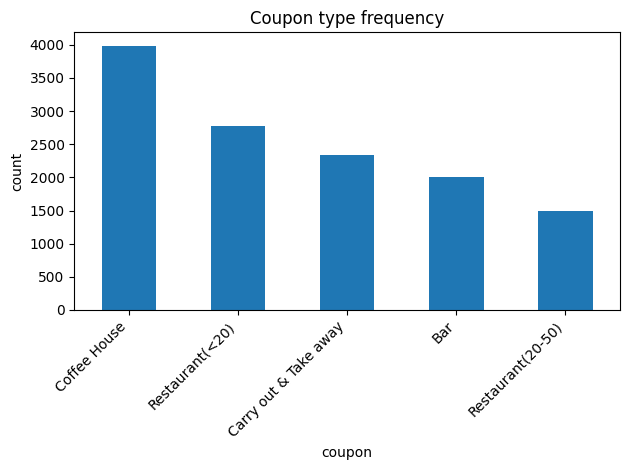

In [17]:
order = data["coupon"].value_counts().index
data["coupon"].value_counts().reindex(order).plot(kind="bar")
plt.xlabel("coupon")
plt.ylabel("count")
plt.title("Coupon type frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

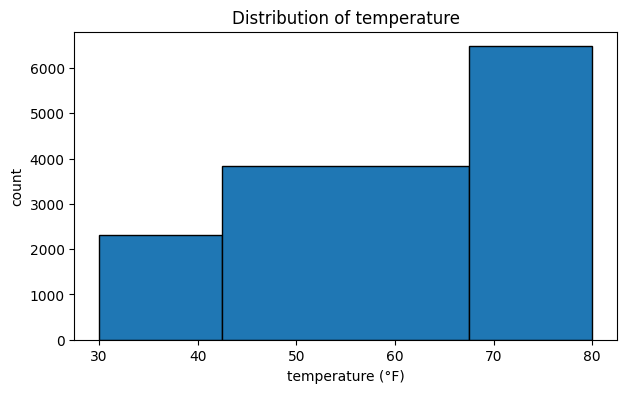

In [18]:
plt.figure(figsize=(7, 4))
plt.hist(data["temperature"], bins=[30, 42.5, 67.5, 80], edgecolor="black")
plt.xlabel("temperature (°F)")
plt.ylabel("count")
plt.title("Distribution of temperature")
plt.show()

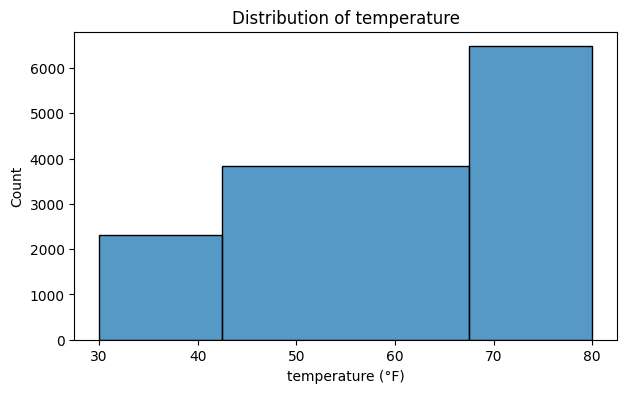

In [19]:
plt.figure(figsize=(7, 4))
sns.histplot(data=data, x="temperature", bins=[30, 42.5, 67.5, 80], edgecolor="black")
plt.xlabel("temperature (°F)")
plt.title("Distribution of temperature")
plt.show()

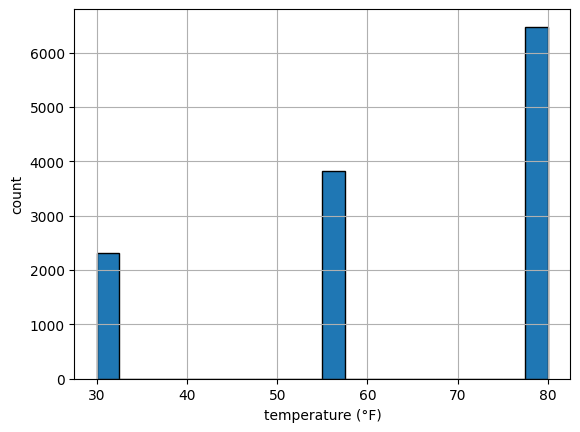

In [20]:
data["temperature"].hist(bins=20, edgecolor="black")
plt.xlabel("temperature (°F)")
plt.ylabel("count")
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [21]:
bar_coupons = data[data["coupon"] == "Bar"].copy()

In [22]:
bar_coupons.shape
bar_coupons["coupon"].value_counts()

coupon
Bar    2010
Name: count, dtype: int64

2. What proportion of bar coupons were accepted?


In [23]:
python -c "import pandas as pd; d=pd.read_csv(r'c:\Users\fmasood005\OneDrive - PwC\Projects\Berkeley-Ml-AI-courses\Module5\assignment5_1\data\coupons.csv'); b=d[d['coupon']=='Bar']; print('n', len(b)); print('accepted (Y=1)', b['Y'].sum()); print('proportion', b['Y'].mean())"

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 39-40: truncated \UXXXXXXXX escape (1103472924.py, line 1)

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [24]:
fewer = ["never", "less1", "1~3"]
more = ["4~8", "gt8"]

bar_fewer = bar_coupons[bar_coupons["Bar"].isin(fewer)]
bar_more = bar_coupons[bar_coupons["Bar"].isin(more)]

print("3 or fewer / month — n:", len(bar_fewer), "acceptance:", bar_fewer["Y"].mean())
print("More than 3 / month — n:", len(bar_more), "acceptance:", bar_more["Y"].mean())

3 or fewer / month — n: 1790 acceptance: 0.370391061452514
More than 3 / month — n: 199 acceptance: 0.7688442211055276


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [26]:

import pandas as pd
d=pd.read_csv(r'data\coupons.csv')
b=d[d['coupon']=='Bar'].copy()

# Over 25: exclude below21 and '21' (21 is not over 25)
over25 = ['26','31','36','41','46','50plus']

# Interpretation A: 'more than once' = not never/less1 (1~3, 4~8, gt8) — common in assignments
bar_more_than_once_loose = ['1~3','4~8','gt8']

# Interpretation B: strict frequent — 4+ visits (4~8, gt8) clearly >1; 1~3 is mixed
bar_strict_gt1 = ['4~8','gt8']  # clearly more than 3 visits/month actually

def compare(bar_list, label):
    mask = b['Bar'].isin(bar_list) & b['age'].isin(over25)
    target = b[mask]
    other = b[~mask]
    # exclude NaN Bar from analysis?
    print('---', label, '---')
    print('  Target n:', len(target), 'rate:', target['Y'].mean() if len(target) else None)
    print('  Other n:', len(other), 'rate:', other['Y'].mean() if len(other) else None)
    print('  Diff:', (target['Y'].mean() - other['Y'].mean()) if len(target) and len(other) else None)

compare(bar_more_than_once_loose, 'Loose: Bar in 1~3,4~8,gt8 AND age over25')
compare(bar_strict_gt1, 'Strict: Bar in 4~8,gt8 AND age over25')

# Also: loose bar + over25 vs rest, dropping NaN Bar
b2 = b.dropna(subset=['Bar'])
mask = b2['Bar'].isin(bar_more_than_once_loose) & b2['age'].isin(over25)
print('--- Loose, dropna Bar ---')
print('  Target:', b2[mask]['Y'].mean(), 'n', len(b2[mask]))
print('  Other:', b2[~mask]['Y'].mean(), 'n', len(b2[~mask]))


--- Loose: Bar in 1~3,4~8,gt8 AND age over25 ---
  Target n: 420 rate: 0.6952380952380952
  Other n: 1597 rate: 0.33500313087038197
  Diff: 0.36023496436771324
--- Strict: Bar in 4~8,gt8 AND age over25 ---
  Target n: 136 rate: 0.7720588235294118
  Other n: 1881 rate: 0.3838383838383838
  Diff: 0.388220439691028
--- Loose, dropna Bar ---
  Target: 0.6952380952380952 n 420
  Other: 0.3343908629441624 n 1576


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [28]:
import pandas as pd
d=pd.read_csv(r'data\coupons.csv')
b=d[d['coupon']=='Bar'].copy()

bar_more = ['1~3','4~8','gt8']
farm_occ = 'Farming Fishing & Forestry'

mask = (
    b['Bar'].isin(bar_more) &
    (b['passanger'] != 'Kid(s)') &
    (b['occupation'] != farm_occ)
)
target = b[mask]
others = b[~mask]

print('Target n:', len(target), 'rate:', target['Y'].mean())
print('Others n:', len(others), 'rate:', others['Y'].mean())
print('Diff:', target['Y'].mean() - others['Y'].mean())

# breakdown: how many in bar with kid vs farm
print()
print('Kid(s) bar rows:', (b['passanger']=='Kid(s)').sum())
print('Farming occupation bar rows:', (b['occupation']==farm_occ).sum())
print('NaN Bar:', b['Bar'].isna().sum())


Target n: 551 rate: 0.7132486388384754
Others n: 1466 rate: 0.296043656207367
Diff: 0.41720498263110845

Kid(s) bar rows: 206
Farming occupation bar rows: 9
NaN Bar: 21


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [30]:

import pandas as pd
d=pd.read_csv(r'data\coupons.csv')
print('maritalStatus:', d['maritalStatus'].unique())
print('RestaurantLessThan20:', sorted(d['RestaurantLessThan20'].dropna().unique()))
print('income:', d['income'].unique())
print('age:', sorted(d['age'].unique()))


maritalStatus: ['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
RestaurantLessThan20: ['1~3', '4~8', 'gt8', 'less1', 'never']
income: ['$37500 - $49999' '$62500 - $74999' '$12500 - $24999' '$75000 - $87499'
 '$50000 - $62499' '$25000 - $37499' '$100000 or More' '$87500 - $99999'
 'Less than $12500']
age: ['21', '26', '31', '36', '41', '46', '50plus', 'below21']


In [31]:

import pandas as pd
d=pd.read_csv(r'data\coupons.csv')

bar_freq = ['1~3','4~8','gt8']
under_30 = ['below21','21','26']
cheap_often = ['4~8','gt8']  # more than 4 times / month to cheap restaurants
income_lt50 = ['Less than \$12500', '\$12500 - \$24999', '\$25000 - \$37499', '\$37500 - \$49999']

cond1 = d['Bar'].isin(bar_freq) & (d['passanger'] != 'Kid(s)') & (d['maritalStatus'] != 'Widowed')
cond2 = d['Bar'].isin(bar_freq) & d['age'].isin(under_30)
cond3 = d['RestaurantLessThan20'].isin(cheap_often) & d['income'].isin(income_lt50)

mask = cond1 | cond2 | cond3
target = d[mask]
others = d[~mask]

print('Target n:', len(target), 'rate:', target['Y'].mean())
print('Others n:', len(others), 'rate:', others['Y'].mean())
print('Diff:', target['Y'].mean() - others['Y'].mean())

# overlap counts
print()
print('cond1 only sum:', cond1.sum())
print('cond2 only sum:', cond2.sum())
print('cond3 only sum:', cond3.sum())
print('union:', mask.sum())


Target n: 3736 rate: 0.6241970021413277
Others n: 8948 rate: 0.5451497541350022
Diff: 0.07904724800632545

cond1 only sum: 3696
cond2 only sum: 2272
cond3 only sum: 0
union: 3736


In [32]:

import pandas as pd
d=pd.read_csv(r'data\coupons.csv')

bar_freq = ['1~3','4~8','gt8']
under_30 = ['below21','21','26']
cheap_often = ['4~8','gt8']
income_lt50 = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']

cond1 = d['Bar'].isin(bar_freq) & (d['passanger'] != 'Kid(s)') & (d['maritalStatus'] != 'Widowed')
cond2 = d['Bar'].isin(bar_freq) & d['age'].isin(under_30)
cond3 = d['RestaurantLessThan20'].isin(cheap_often) & d['income'].isin(income_lt50)

mask = cond1 | cond2 | cond3
target = d[mask]
others = d[~mask]

print('Target n:', len(target), 'rate:', target['Y'].mean())
print('Others n:', len(others), 'rate:', others['Y'].mean())
print('Diff:', target['Y'].mean() - others['Y'].mean())

print('cond1:', cond1.sum(), 'cond2:', cond2.sum(), 'cond3:', cond3.sum(), 'union:', mask.sum())


Target n: 5152 rate: 0.6053959627329193
Others n: 7532 rate: 0.5431492299522039
Diff: 0.06224673278071535
cond1: 3696 cond2: 2272 cond3: 2279 union: 5152


In [33]:

import pandas as pd
d=pd.read_csv(r'data\coupons.csv')
cheap_often = ['4~8','gt8']
income_lt50 = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']

a = d['RestaurantLessThan20'].isin(cheap_often)
b = d['income'].isin(income_lt50)
print('cheap freq 4~8/gt8:', a.sum())
print('income lt50:', b.sum())
print('both:', (a&b).sum())

# cross-tab
sub = d[a & b]
print('sub shape', len(sub))
# show RestaurantLessThan20 and income for people with cheap 4~8
x = d[d['RestaurantLessThan20'].isin(cheap_often)]
print('income value counts for cheap 4+ visits:')
print(x['income'].value_counts())


cheap freq 4~8/gt8: 4865
income lt50: 6691
both: 2279
sub shape 2279
income value counts for cheap 4+ visits:
income
$100000 or More     912
$37500 - $49999     658
$12500 - $24999     612
$50000 - $62499     565
$25000 - $37499     550
Less than $12500    459
$62500 - $74999     424
$75000 - $87499     394
$87500 - $99999     291
Name: count, dtype: int64


In [34]:

import pandas as pd
d=pd.read_csv(r'data\coupons.csv')
for x in sorted(d['income'].unique()):
    print(repr(x))


'$100000 or More'
'$12500 - $24999'
'$25000 - $37499'
'$37500 - $49999'
'$50000 - $62499'
'$62500 - $74999'
'$75000 - $87499'
'$87500 - $99999'
'Less than $12500'


In [35]:
import pandas as pd; dol=chr(36); income_lt50 = ['Less than '+dol+'12500', dol+'12500 - '+dol+'24999', dol+'25000 - '+dol+'37499', dol+'37500 - '+dol+'49999']; d=pd.read_csv(r'data\\coupons.csv'); print('lt50 count', d['income'].isin(income_lt50).sum()); bar_freq = ['1~3','4~8','gt8']; under_30 = ['below21','21','26']; cheap_often = ['4~8','gt8']; cond1 = d['Bar'].isin(bar_freq) & (d['passanger'] != 'Kid(s)') & (d['maritalStatus'] != 'Widowed'); cond2 = d['Bar'].isin(bar_freq) & d['age'].isin(under_30); cond3 = d['RestaurantLessThan20'].isin(cheap_often) & d['income'].isin(income_lt50); mask = cond1 | cond2 | cond3; t=d[mask]; o=d[~mask]; print('Target', len(t), t['Y'].mean()); print('Others', len(o), o['Y'].mean()); print('cond1', cond1.sum(), 'cond2', cond2.sum(), 'cond3', cond3.sum(), 'union', mask.sum())

lt50 count 6691
Target 5152 0.6053959627329193
Others 7532 0.5431492299522039
cond1 3696 cond2 2272 cond3 2279 union 5152


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
Hypothesis
Drivers who accept bar coupons look more like people who already go to bars regularly, are in situations where a bar stop is socially “allowed,” and are not in the lowest-engagement groups. Acceptance is less about random willingness and more about fit between the offer and existing behavior and context.

What the numbers suggest (association, not proof)
Habit / relevance
Acceptance is much higher among people who report going to bars more often (e.g. 4~8, gt8) than among rare visitors (never, less1, 1~3). That fits the idea that the coupon matches existing habits and feels usable, not odd or out of character.

Social context
When you add no kid in the car (and similar filters), acceptance stays high relative to “everyone else.” That supports a hypothesis that who is in the vehicle shapes whether a bar detour is acceptable—not just personal taste.

Demographics and life situation
Splits by age (e.g. over 25) and marital status (e.g. not widowed in one of your rules) point to life stage / social situation mattering, though you should describe them carefully as patterns in the survey, not as universal rules about all drivers.

Broader eating-out / income picture
The combined OR rule (bar behavior, age, cheap restaurants + income) still shows a modest lift vs everyone else, which is consistent with several paths to acceptance (bar-centric vs budget / frequent cheap dining), not a single.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [36]:
import pandas as pd; d=pd.read_csv(r'data\coupons.csv'); print(d['coupon'].value_counts()); print(); 
for c in d['coupon'].unique():
    if c=='Bar': continue
    sub=d[d['coupon']==c]
    print('===', c, 'n=', len(sub), 'overall accept', sub['Y'].mean().round(3))
    print(sub.groupby('passanger')['Y'].agg(['count','mean']).round(3))

coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(20-50)        1492
Name: count, dtype: int64

=== Restaurant(<20) n= 2786 overall accept 0.707
           count   mean
passanger              
Alone       1435  0.638
Friend(s)    826  0.801
Kid(s)       267  0.723
Partner      258  0.771
=== Coffee House n= 3996 overall accept 0.499
           count   mean
passanger              
Alone       2256  0.438
Friend(s)   1228  0.597
Kid(s)       207  0.483
Partner      305  0.570
=== Carry out & Take away n= 2393 overall accept 0.735
           count   mean
passanger              
Alone       1405  0.727
Friend(s)    739  0.758
Kid(s)       152  0.704
Partner       97  0.732
=== Restaurant(20-50) n= 1492 overall accept 0.441
           count   mean
passanger              
Alone       1009  0.422
Friend(s)    168  0.464
Kid(s)       174  0.374
Partner      141  0.631


In [38]:
focus = data[data["coupon"] == "Coffee House"].copy()  # or another label, exact string from data

In [ ]:
Independent Investigation, using your dataset and the same spirit as the bar-coupon work.

1. Pick one other coupon type
From coupons.csv, the non-bar types are:

Coupon	Approx. n	Overall acceptance (Y mean)
Coffee House	3,996	~0.50
Restaurant(<20)	2,787	~0.71
Carry out & Take away	2,393	~0.74
Restaurant(20–50)	1,492	~0.44
Good choices for a short write-up

Coffee House — Overall acceptance is near 50/50 and acceptance varies a lot by passenger (see below), so you can tell a clear story.
Restaurant(20–50) — Uptake is lower overall, and Partner stands out vs other passengers (interesting contrast to bar/cheap patterns).
2. Define your subset
focus = data[data["coupon"] == "Coffee House"].copy()  # or another label, exact string from data
Use the exact coupon string (e.g. "Coffee House", "Restaurant(<20)").

3. Passenger and acceptance (core ask)
Group by passanger (spelling in the file) and compare Y:

focus.groupby("passanger")["Y"].agg(["count", "mean"])
Illustrative pattern (Coffee House, full file): acceptance is roughly highest with Friend(s), mid with Partner, lower with Kid(s) and Alone — so you can hypothesize that social context matters for this coupon, similar in spirit to bar but with different magnitudes.

Illustrative pattern (Restaurant(20–50)): Partner has much higher acceptance than Alone / Friend(s) / Kid(s) — worth discussing price / occasion (expensive meal as a couple activity).

4. Go beyond passengers (like the bar section)
To “determine characteristics,” add a few context variables on the same subset:

weather, time, temperature, destination
expiration (2h vs 1d)
Optional: age, income, gender — compare groups with groupby or side-by-side acceptance rates.
Example:

focus.groupby("expiration")["Y"].mean()
focus.groupby("weather")["Y"].mean()
5. What to write
Why this coupon (e.g. most common, or strongest passenger contrast).
Table or plot: acceptance by passanger (bar chart of rates or counts).
1–2 sentences: who accepts more vs less (e.g. friends vs alone).
Hypothesis: tie behavior to social setting, time/money, or scenario — and state that this is association in survey data, not proof of causation.
6. Hypothesis examples (tailor to the coupon you choose)
Coffee House: Acceptance is higher when the scenario involves friends or a partner than when alone, consistent with coffee as a social stop.
Expensive restaurant: Acceptance may cluster with Partner and with longer expiration or specific times, if your tables support it.
You do not need every coupon type—one deep dive on Coffee House or Restaurant(20–50) is enough for “independent investigation” if you justify it with numbers and a clear passenger-focused comparison.